## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).



## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [1]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

In [2]:
import io  # Helps read data in memory
import pandas as pd  # Used to build and handle data tables
from azure.storage.blob import BlobServiceClient  # Connects Python to the Azure cloud

# Cloud Login Details ---
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"  # The folder name
blob_name = "house_sales_prediction.csv"  # The file name

# Task 1.2: Download the Data ---
blob_service_client = BlobServiceClient.from_connection_string(connect_str)  # Logs into Azure
blob_client = blob_service_client.get_blob_client(container=container_name, blob=blob_name)  # Finds the file

# Download the CSV content into memory
download_stream = blob_client.download_blob()
csv_data = download_stream.readall()

# Create the dataframe with the required name
df_house_price = pd.read_csv(io.BytesIO(csv_data))

# Task 1.3: Display the first few rows ---
print("--- First 5 Rows ---")
display(df_house_price.head())

# Task 1.4: Check the data types and null values ---
print("\n--- Data Info and Null Values ---")
display(df_house_price.info())


--- First 5 Rows ---



--- Data Info and Null Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Square_Feet         500 non-null    float64
 1   Num_Bedrooms        500 non-null    int64  
 2   Num_Bathrooms       500 non-null    int64  
 3   Num_Floors          500 non-null    int64  
 4   Garage_Size         500 non-null    int64  
 5   Location_Score      500 non-null    float64
 6   Distance_to_Center  500 non-null    float64
 7   Price               500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 31.4 KB


## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

In [3]:
#Task 2.1. Check summary statistics for the dataset.
# Show mean, median, min, max, and standard deviation for all columns
from IPython.display import display
display(df_house_price.describe())

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center,Price
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,174.640428,2.958000,1.976000,1.964000,30.174000,5.164410,10.469641,582209.629531
std,74.672102,1.440968,0.820225,0.802491,11.582575,2.853489,5.588197,122273.390347
min,51.265396,1.000000,1.000000,1.000000,10.000000,0.004428,0.062818,276892.470100
25%,110.319923,2.000000,1.000000,1.000000,20.000000,2.760650,6.066754,503080.344175
50%,178.290937,3.000000,2.000000,2.000000,30.000000,5.206518,10.886066,574724.113350
75%,239.031220,4.000000,3.000000,3.000000,41.000000,7.732933,15.072590,665942.301300
max,298.241199,5.000000,3.000000,3.000000,49.000000,9.995439,19.927966,960678.274300


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 11.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


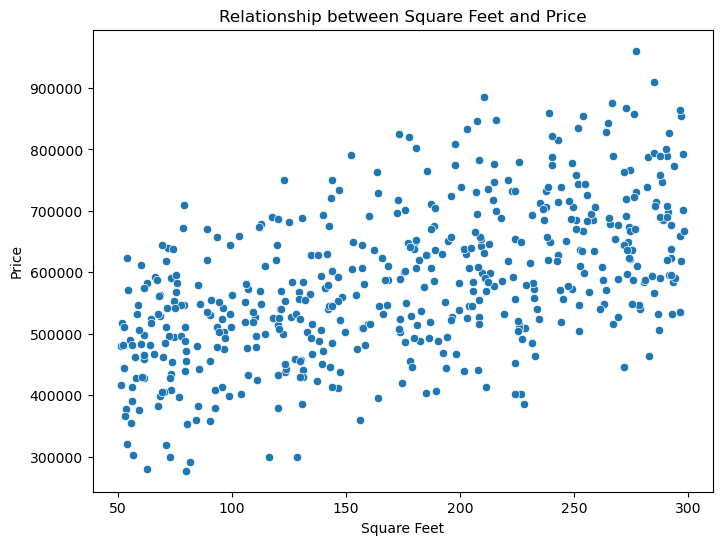

In [4]:

import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

# Task 2.2: Scatter plot of Square Feet vs Price

# Create a plotting window 8 inches wide and 6 inches tall
plt.figure(figsize=(8,6))

# Draw dots using 'Square_Feet' on the X-axis and 'Price' on the Y-axis
sns.scatterplot(x='Square_Feet', y='Price', data=df_house_price)

# Add titles and text labels to the chart axes
plt.title('Relationship between Square Feet and Price')
plt.xlabel('Square Feet')
plt.ylabel('Price')

# Render the final chart on the screen
plt.show()






##### Task 2.2: What this Chart Tells Us (EDA)

* **The Rule:** The dots go up from left to right. This shows a **positive relationship**—bigger houses generally cost more money.
* **The Variation:** The dots are very spread out vertically. This means two houses with the **exact same size** can have completely different prices. 
* **The Insight:** Size matters, but it does not tell the whole story. Other factors—like **Location** or **Number of Bedrooms**—must be causing these massive price differences.


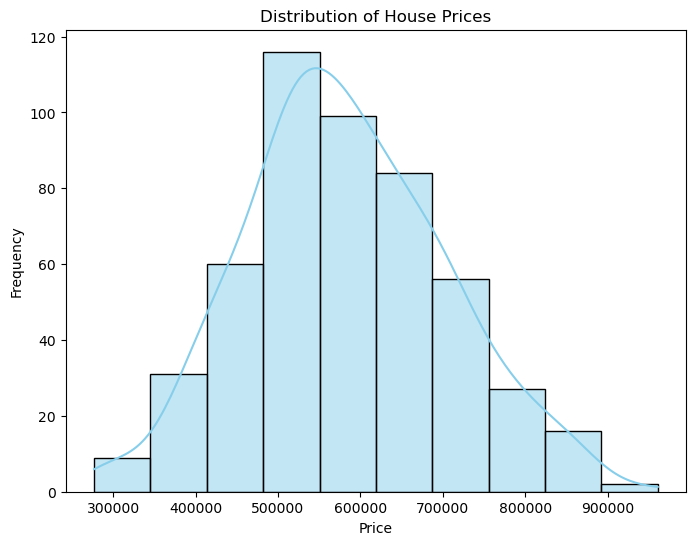

In [5]:
#Task 2.3: Distribution of House Prices with a Trend Curve (KDE)

# Create a plotting window 8 inches wide and 6 inches tall
plt.figure(figsize=(8,6))

# Draw a bar chart of prices split into 10 groups (bins)
# kde=True adds a smooth trend line over the bars
sns.histplot(df_house_price['Price'], bins=10,color='skyblue', kde=True)

# Add titles and text labels to the chart axes
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
# Render the final chart on the screen
plt.show()

##### Task 2.3: What this Chart Tells Us (EDA)

* **The Most Common Price:** The tallest bar shows that most houses cost between **\$500,000 and \$600,000**.
* **The Distribution:** The graph looks like a hill with a longer "tail" stretching out to the right side.
* **The Insight:** This tail means our data includes a few **very expensive luxury houses** (priced up to \$950,000). These high numbers pull the overall average up.


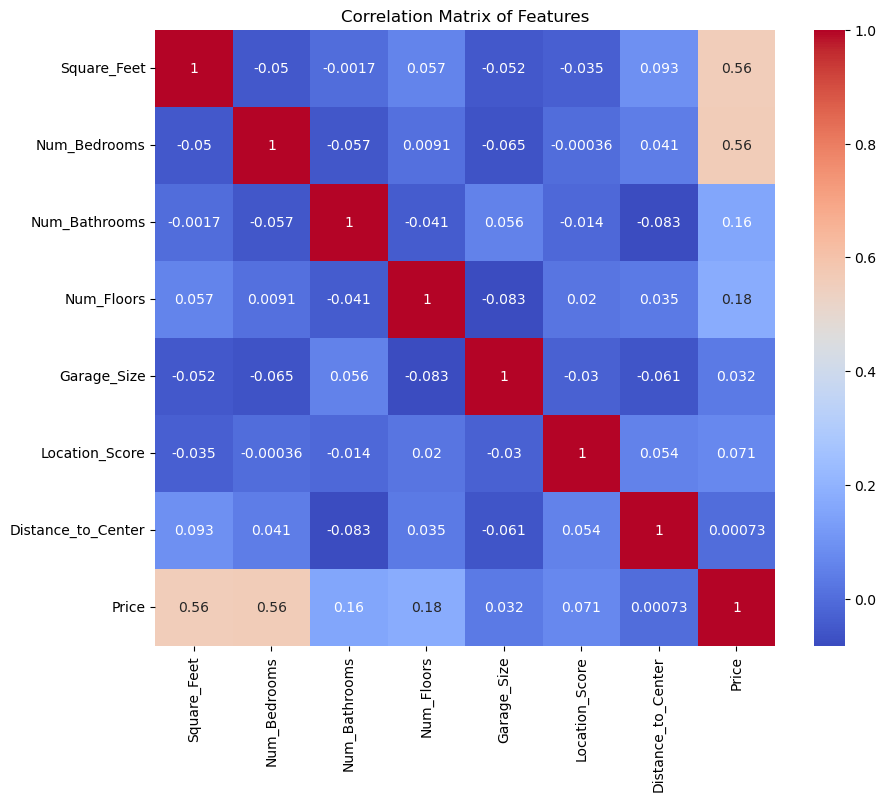

In [6]:

# Task 2.4: Heatmap of Feature Correlations

# Create a large plotting window 10 inches wide and 8 inches tall
plt.figure(figsize=(10,8))

# Calculate data correlations and show them as a color-coded grid
# annot=True prints the actual relationship numbers inside the boxes
# cmap='coolwarm' uses blue for negative relationships and red for positive ones
sns.heatmap(df_house_price.corr(), annot=True, cmap='coolwarm')

# Add a title to the grid
plt.title('Correlation Matrix of Features')

# Render the final chart on the screen
plt.show()


##### Task 2.4: What this Chart Tells Us (EDA)

* **The Meaning of Colors:** **Red** means two features have a strong relationship. **Blue** means they have a weak relationship or no connection at all.
* **The Strongest Factors:** **`Square_Feet` (0.56)** and **`Num_Bedrooms` (0.56)** have the highest numbers when compared to `Price`. This proves that house size and bedroom count affect the price the most.
* **The Weakest Factors:** Features like **`Garage_Size` (0.032)** and **`Distance_to_Center` (0.00073)** are deep blue. This tells us they have almost zero impact on the house price in this dataset.


###### Summary of Visual Insights from Task 2
* **The Scatter Plot:** Shows that bigger houses generally cost more money. However, the wide data cloud proves huge price variations exist for the same house size.
* **The Histogram:** Shows most house prices cluster around \$500k–\$600k. A long right tail reveals a few extremely expensive luxury houses.
* **The Correlation Matrix:** Confirms `Square_Feet` (0.56) and `Num_Bedrooms` (0.56) drive prices. Features like `Garage_Size` and `Distance_to_Center` have almost zero impact.


## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# task 3.1 Define the dataset into features (X) and target variable (y)
feature_cols= ['Square_Feet', 
    'Num_Bedrooms', 
    'Num_Bathrooms', 
    'Num_Floors', 
    'Garage_Size', 
    'Location_Score', 
    'Distance_to_Center']
# Extract these specific columns for X
X = df_house_price[feature_cols]

# Extract the Price column for y
y = df_house_price['Price']

# Check that the data split correctly
print("Input features loaded:")
display(X.head())

# Split the data into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#display(X)
#display(y)
display(X_train)
display(y_train)
display(X_test)
display(y_test)

Input features loaded:


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center
0,143.635030,1,3,3,48,8.297631,5.935734
1,287.678577,1,2,1,37,6.061466,10.827392
2,232.998485,1,3,2,14,2.911442,6.904599
3,199.664621,5,2,2,17,2.070949,8.284019
4,89.004660,4,3,3,34,1.523278,14.648277


,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center
249,263.252364,3,3,1,16,3.119840,1.212098
433,75.280669,5,1,3,16,4.994318,13.487993
19,122.807285,5,2,3,28,7.769280,8.294717
322,215.049344,5,1,3,19,9.789575,15.536067
332,53.598372,1,1,1,39,6.307005,15.611121
...,...,...,...,...,...,...,...
106,152.595731,2,3,1,17,8.082754,13.549468
270,252.340289,4,1,1,43,9.615133,18.313445
348,143.653154,4,3,2,38,5.636600,13.284034
435,225.242283,1,2,3,27,1.443876,0.909050


249    547951.7365
433    595883.5153
19     750687.6199
322    747398.2798
332    377060.0040
          ...     
106    605185.1457
270    635900.8402
348    749942.5079
435    503593.3206
102    299477.8500
Name: Price, Length: 400, dtype: float64

,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Garage_Size,Location_Score,Distance_to_Center
361,210.822055,2,1,2,37,0.066821,13.161652
73,253.865357,3,2,2,41,4.589635,14.861631
374,67.797162,4,1,1,15,7.394082,17.392122
155,110.513818,1,3,3,37,8.888874,9.230459
104,276.891618,4,1,1,47,1.778881,10.421464
...,...,...,...,...,...,...,...
347,61.326002,4,1,2,40,3.732598,19.835458
86,232.401545,3,1,3,43,3.927938,12.168179
75,232.251792,1,1,1,12,1.760955,10.911704
438,226.560557,3,1,1,15,5.000801,13.400651


361    591058.7089
73     667693.0003
374    532377.5802
155    478489.2990
104    730197.4806
          ...     
347    464849.9178
86     572360.6499
75     557752.8374
438    649930.0523
15     523527.9747
Name: Price, Length: 100, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split

# Task 3.2: Separate features (X) from the target price (y)
# Replace 'Price' with the exact name of your house price column
X = df_house_price.drop(columns=['Price'])
y = df_house_price['Price']

# Task 3.2: Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [9]:
# Task 3.3: Train the Multiple Linear Regression (MLR) Model ---
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
mlr_model = LinearRegression()

# Train the model using the training data
mlr_model.fit(X_train, y_train)

# Predict prices for the test data
y_pred_mlr = mlr_model.predict(X_test)
print("Multiple Linear Regression model successfully trained!")

# Display a table with Actual vs Predicted values
results_mlr = pd.DataFrame({'Actual Salary': y_test, 'Predicted Salary': y_pred_mlr})
display(results_mlr)




🏃 View run jovial_pin_9xlb3f0c at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/813403c9-6fad-48fb-818c-3c39cacef362/#/experiments/a7db6cfa-9038-4033-835f-7f60ece5308d/runs/54316266-e4cf-4a67-8142-04259ee8e4dc
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/813403c9-6fad-48fb-818c-3c39cacef362/#/experiments/a7db6cfa-9038-4033-835f-7f60ece5308d


Multiple Linear Regression model successfully trained!


,Actual Salary,Predicted Salary
361,591058.7089,525669.926934
73,667693.0003,668141.051861
374,532377.5802,467168.904743
155,478489.2990,498375.548472
104,730197.4806,691359.973840
...,...,...
347,464849.9178,493645.118779
86,572360.6499,643248.170875
75,557752.8374,454235.083741
438,649930.0523,564489.566281


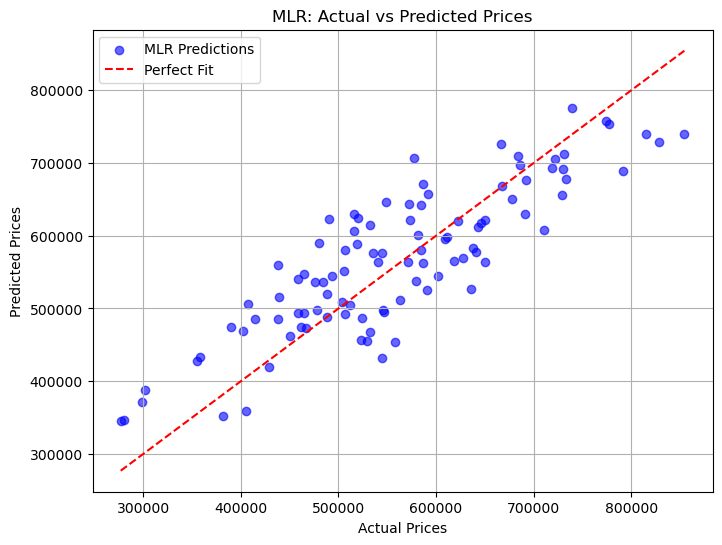

In [10]:
# --- Task 3.4: Visualise Predicted vs. Actual Prices ---
import matplotlib.pyplot as plt

# Set chart size
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted prices
plt.scatter(y_test, y_pred_mlr, alpha=0.6, color='blue', label='MLR Predictions')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')

# Labels and titles
plt.title('MLR: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()





 ##### MLR Graph Performance
 
###### Chart Basics
* **X-Axis:** The real house prices.
* **Y-Axis:** The prices the model guessed.
* **Red Line:** 100% perfect predictions.

 ###### Model Performance
* **Good Accuracy:** Most of the blue dots cluster tightly along the red line. This means for most normal houses, your model's **After** price is very close to the **Before** price.
* **Under-Guesstimate (Below the Red Line):** For the highly expensive houses on the far right (over $800,000), the blue dots sit below the red line. This means your model is under-predicting the value of luxury houses.
* **Over-Guesstimate (Above the Red Line):** For some cheaper houses on the left (under $400,000), the dots sit above the red line. This means the model over-guessed their value.

###### Final Takeaway
The model is reliable for normal, average houses but struggles to guess extreme prices correctly.



In [11]:
# --- Task 3.5: Evaluate the Model ---
from sklearn.metrics import root_mean_squared_error

# Calculate the MLR error score (This defines rmse_mlr for Task 4.3!)
rmse_mlr = root_mean_squared_error(y_test, y_pred_mlr)

# Print the score
print(f"MLR RMSE: {rmse_mlr:.2f}")



MLR RMSE: 63952.38


## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

# Create the model with 100 trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using training data
rf_model.fit(X_train, y_train)

# Predict prices using test data
y_pred_rf = rf_model.predict(X_test)

# Calculate the error score (RMSE)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

# Print the final error score
print(f"Random Forest RMSE: {rmse_rf:.2f}")




🏃 View run good_gold_4jv6mwpx at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/813403c9-6fad-48fb-818c-3c39cacef362/#/experiments/a7db6cfa-9038-4033-835f-7f60ece5308d/runs/511f7b5d-5e29-49cb-a839-09baf22b1c29
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/813403c9-6fad-48fb-818c-3c39cacef362/#/experiments/a7db6cfa-9038-4033-835f-7f60ece5308d


Random Forest RMSE: 71733.36


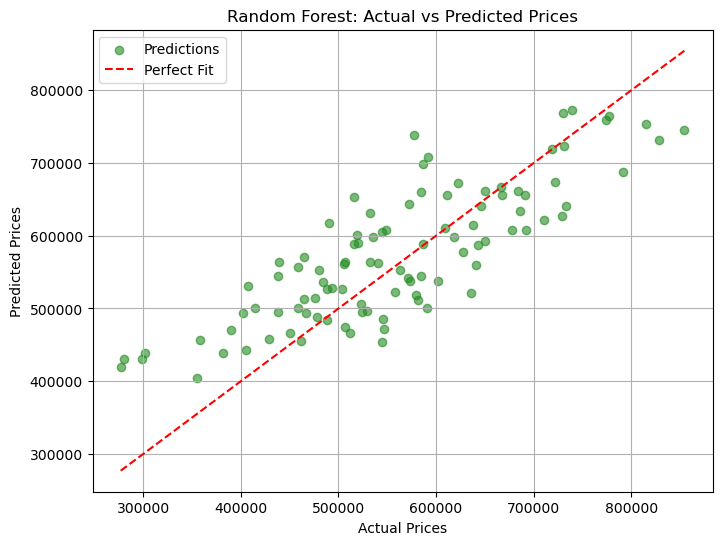

In [13]:
import matplotlib.pyplot as plt

# Set the size of the plot
plt.figure(figsize=(8, 6))

# Plot actual prices vs predicted prices
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='forestgreen', label='Predictions')

# Draw a red diagonal line for perfect accuracy
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')

# Add titles and labels to the chart
plt.title('Random Forest: Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.grid(True)

# Show the final plot
plt.show()





##### Random Forest Graph Performance

###### Chart Basics
* **X-Axis:** The real house prices.
* **Y-Axis:** The prices the model guessed.
* **Red Line:** 100% perfect predictions.

###### Model Performance
* **Good for Average Homes:** Between $500k and $700k, the green dots cluster well around the red line. This means the model is generally accurate for normal houses.
* **Bad for Cheap Homes:** Under $400k, the green dots sit noticeably high above the red line. This means the model heavily **over-guesses** the value of cheaper homes.
* **Bad for Luxury Homes:** Over $800k, the green dots flatten out below the red line. This means the model heavily **under-guesses** the value of expensive homes.

###### Final Takeaway
Just like the MLR model, the Random Forest model is reliable for normal houses but makes major errors on very cheap and very expensive properties.



In [14]:
# Compare the two error scores
print(f"MLR RMSE: {rmse_mlr:.2f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}\n")

# The model with the lower number wins!
print("--- Final Model Comparison ---")
if rmse_mlr < rmse_rf:
    print("🏆 Multiple Linear Regression (MLR) wins! It has a lower error score.")
elif rmse_rf < rmse_mlr:
    print("🏆 Random Forest wins! It has a lower error score.")
else:
    print("🤝 Both models performed exactly the same!")


MLR RMSE: 63952.38
Random Forest RMSE: 71733.36

--- Final Model Comparison ---
🏆 Multiple Linear Regression (MLR) wins! It has a lower error score.


## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

##### Conclusion and Insights
##### Insights and Recommendations

###### Which Model is Better?
* **The Winner:** The **Multiple Linear Regression (MLR)** model won.
* **Why:** In data science, a lower score means fewer guessing mistakes. On average, the MLR model was off by **$63,952**, while the Random Forest model was off by a larger **$71,733**. This means MLR is roughly $7,781 more accurate per house.

###### What the Graphs Showed Us
* **Good for Normal Houses:** Both models are very good at guessing the prices of average, mid-range houses ($500,000 to $700,000). The dots pack tightly together in the middle of the charts.
* **Bad for Expensive Houses:** Both models struggle with luxury houses over $800,000. They consistently **under-guessed** the prices, predicting them as much cheaper than they actually are.
* **Bad for Cheap Houses:** Both models struggle with cheaper houses under $400,000. They consistently **over-guessed** their values, predicting them as more expensive than they actually are.

###### Simple Ways to Improve Both Models
1. **Smooth Out the Prices:** Use a quick math formula (called a Log Transformation) to shrink the giant luxury house prices. This levels out the playing field and stops the models from getting confused by massive numbers.
2. **Delete Useless Information:** Our charts showed that minor features like garage size have almost zero effect on a house's value. We should remove them so the computer can focus entirely on what matters most: house size and the number of bedrooms.
3. **Get More Information:** Size and bedrooms do not tell the whole story. To stop the models from guessing incorrectly, we need to feed them missing real-world data like **Neighborhood Safety**, **School Quality**, and **Home Condition**.


##### House Price Prediction Project Overview

 ###### 1. Project Goal
The objective of this project is to build and train a machine learning model that can accurately predict house prices based on physical features like square footage and the number of bedrooms. 

###### Step 2: Exploratory Data Analysis (EDA)
Before building models, we explored the dataset to find key trends and patterns:
* **The Main Driver:** Our scatter plot showed a positive trend—bigger houses generally cost more money.
* **The Data Curve:** Our price histogram showed that most houses cost between $500,000 and $600,000, with a few premium luxury houses stretching the right side of the graph.
* **Feature Importance:** Our correlation matrix confirmed that house size and bedroom counts have the strongest impact on house prices.

###### Step 3 & 4: Model Building and Prediction
We trained two different machine learning algorithms using the training data and tested their performance:
1. **Multiple Linear Regression (MLR):** A baseline model that uses a straight line approach.
2. **Random Forest (RF):** A more complex tree-based model designed to capture non-linear trends.

###### Step 5: Final Evaluation and Conclusion
We compared both models side-by-side using evaluation charts and their overall error scores (**RMSE**):
* **MLR RMSE Score:** 63,952.38
* **Random Forest RMSE Score:** 71,733.36
* **The Winner:** **Multiple Linear Regression (MLR)** performed better because it achieved a lower error score, making it roughly $7,781 more accurate per house.
* **Shared Weaknesses:** Looking at both performance graphs, both models are highly accurate for normal houses ($500k to $700k), but both struggle at the extremes—over-guessing cheap homes and under-guessing luxury homes.


Good work. Well done
